In [45]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

def binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    metrics = {
        "Accuracy":  (tp + tn) / (tp + tn + fp + fn),
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall":    tp / (tp + fn) if (tp + fn) > 0 else 0,
        "TPR":       tp / (tp + fn) if (tp + fn) > 0 else 0,
        "FPR":       fp / (fp + tn) if (fp + tn) > 0 else 0,
        "TNR":       tn / (tn + fp) if (tn + fp) > 0 else 0,
        "FNR":       fn / (fn + tp) if (fn + tp) > 0 else 0,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

    return pd.Series(metrics)

In [46]:
NEPC_PROJ_PATH = Path("/data/gusev/USERS/jpconnor/data/CAIA/COMPASS")

LLM_LABEL_PATH = NEPC_PROJ_PATH / 'LLM_NEPC_labels/'

OUT_DIR = Path("/data/gusev/USERS/jpconnor/figures/CAIA/COMPASS")
OUT_DIR.mkdir(parents=True, exist_ok=True)

manual_annotations = pd.read_csv(LLM_LABEL_PATH / 'baca_lab_annotations.csv')
nepc_annotations = pd.read_csv(LLM_LABEL_PATH / 'LLM_v3_labels.tsv', sep='\t')
platinum_mrns = pd.read_csv(NEPC_PROJ_PATH / 'mrn_lists/platinum_MRN_list.csv')
platinum_dict = {mrn : True if mrn in platinum_mrns['DFCI_MRN'].unique() else False for mrn in nepc_annotations['DFCI_MRN'].unique()}
nepc_annotations['is_platinum'] = nepc_annotations['DFCI_MRN'].map(platinum_dict)

In [47]:
merged_results = (manual_annotations.drop(columns=['pathology_details', 'manual_platinum_reason'])
                  .merge(nepc_annotations.drop(columns=['has_nepc', 'has_avpc', 'has_molecular_avpc',
                                                        'avpc_criteria', 'visceral_met_pattern', 'num_snippets']), 
                                               on='DFCI_MRN'))
merged_results['manual_NEPC'] = (merged_results['simplified_manual_platinum_reason'].isin(['nepc', 'squamous_transformation']))
merged_results['LLM_NEPC'] = merged_results['primary_label'] == 'nepc'

In [48]:
metrics = binary_metrics(merged_results['manual_NEPC'], merged_results['LLM_NEPC'])

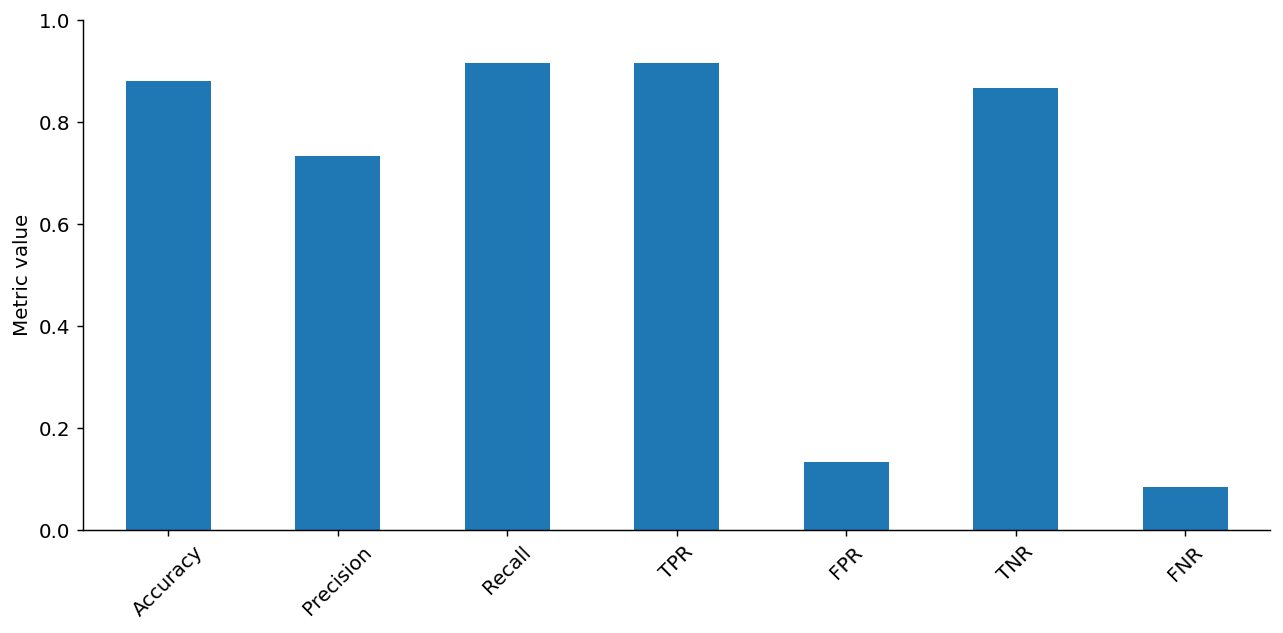

In [49]:
metrics_to_plot = metrics[
    ["Accuracy", "Precision", "Recall", "TPR", "FPR", "TNR", "FNR"]
]

metrics_to_plot.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
platinum_positive_labels = nepc_annotations.loc[nepc_annotations['is_platinum'], 'primary_label'].value_counts().reset_index()
platinum_negative_labels = nepc_annotations.loc[~nepc_annotations['is_platinum'], 'primary_label'].value_counts().reset_index()

In [51]:
platinum_positive_labels['frac'] = platinum_positive_labels['count'] / platinum_positive_labels['count'].sum()
platinum_positive_labels['platinum_status'] = 'positive'

platinum_negative_labels['frac'] = platinum_negative_labels['count'] / platinum_negative_labels['count'].sum()
platinum_negative_labels['platinum_status'] = 'negative'

label_distributions = pd.concat([platinum_positive_labels, platinum_negative_labels])

In [52]:
label_distributions

,primary_label,count,frac,platinum_status
0,avpc,118,0.590000,positive
1,nepc,36,0.180000,positive
2,conventional,30,0.150000,positive
3,biomarker,16,0.080000,positive
0,conventional,1090,0.648038,negative
1,avpc,456,0.271106,negative
2,biomarker,72,0.042806,negative
3,nepc,64,0.038050,negative


<Axes: xlabel='primary_label', ylabel='frac'>

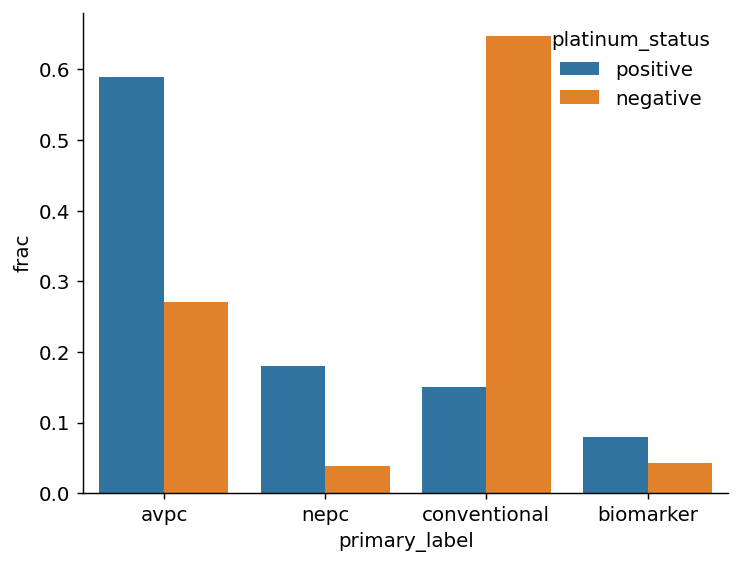

In [53]:
import seaborn as sns
sns.barplot(data=label_distributions, x='primary_label', y='frac', hue='platinum_status')